# SPSFF Plots

Two-panel plots (diagonal + off-diagonal) for each model.

**Data root**: adjust `DATA_ROOT` below to point to the directory containing model output folders.

In [13]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

STYLE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "plot_style.mplstyle")
plt.style.use(STYLE)
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"

DATA_ROOT = "/home/zihanz/spsff/model_code/spsff_code"
OUT_DIR   = "paper_figure"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Unified colorblind-friendly palette (Okabe–Ito + extras) ──
PALETTE = [
    '#0072B2',  # blue
    '#D55E00',  # vermillion
    '#009E73',  # teal
    '#CC79A7',  # pink
    '#E69F00',  # amber
    '#56B4E9',  # sky blue
    '#8B4513',  # brown
    '#000000',  # black
    '#7B68EE',  # slate blue
    '#2F4F4F',  # dark slate gray
    '#DC143C',  # crimson
    '#20B2AA',  # light sea green
    '#FF69B4',  # hot pink
    '#6B8E23',  # olive drab
    '#4169E1',  # royal blue
]

MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', 'd', '<', '>', 'p', 'H', '8']

LINESTYLES = ['-', '--', '-.', ':']

lw_smooth    = 3.0
mark_period  = 120   # marker spacing (same as before)
mark_size    = 9

In [25]:
def plot_spsff(npz_path, out_pdf, n_sec, sym_label,
               key_builder, disp_labels):
    """
    Generic two-panel SPSFF plot.

    Parameters
    ----------
    npz_path    : str   – Path to spsff_data.npz.
    out_pdf     : str   – Output PDF path.
    n_sec       : int   – Number of sectors.
    sym_label   : str   – LaTeX string for the visible group.
    key_builder : (i, j, smooth) -> str
                         Returns the npz key for pair (i, j).
    disp_labels : list  – LaTeX display label for each sector.
    """
    d = np.load(npz_path, allow_pickle=True)
    t = d["t_calc"]

    Ks, Kr = {}, {}
    for i in range(n_sec):
        for j in range(i, n_sec):
            Ks[(i, j)] = d[key_builder(i, j, smooth=True)]
            Kr[(i, j)] = d[key_builder(i, j, smooth=False)]

    # Benchmark values: R_lambda = sector_dim / d_irrep
    sector_dims = d["sector_dims"]
    d_irreps    = d["d_irreps"]
    R_bench     = sector_dims.astype(float) / d_irreps.astype(float)

    t_start, t_end = t[0], t[-1]
    off_pairs = [(i, j) for i in range(n_sec) for j in range(i+1, n_sec)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18*1.3, 8*1.3), sharey=True)

    # ── Panel 1: diagonal ──
    for ci, i in enumerate(range(n_sec)):
        sub = disp_labels[i]
        col = PALETTE[ci % len(PALETTE)]
        mk  = MARKERS[ci % len(MARKERS)]
        ls  = LINESTYLES[ci % len(LINESTYLES)]
        offset = ci * mark_period // max(n_sec, 1)
        label = rf"$K^{{({sym_label})}}_{{ {sub},{sub} }}$"
        ax1.plot(t, Ks[(i, i)],
                 color=col, lw=lw_smooth, ls=ls,
                 marker=mk, markevery=(offset, mark_period),
                 markersize=mark_size, label=label)
        ax1.plot(t, Kr[(i, i)],
                 color=col, lw=lw_smooth, alpha=0.1)

    # Benchmark lines: merge lines with the same R value
    bench_groups = {}
    for i in range(n_sec):
        val = round(R_bench[i])
        bench_groups.setdefault(val, []).append((i, disp_labels[i]))
    for val, members in sorted(bench_groups.items()):
        if len(members) == n_sec:
            combined_label = r"\text{all}"
        elif len(members) > 3:
            combined_label = ",".join(m[1] for m in members[:2]) + r",\ldots"
        else:
            combined_label = ",".join(m[1] for m in members)
        # Use color of the first sector in the group
        col = PALETTE[members[0][0] % len(PALETTE)]
        ax1.axhline(y=val, color=col, ls="--", lw=3.0, alpha=1.0,
                     label=rf"$R_{{{combined_label}}} = {val:.0f}$")

    ax1.set_xlabel(r"$t$", fontsize=40)
    ax1.set_ylabel(rf"$K^{{({sym_label})}}_{{ \lambda_1,\lambda_2 }}(t)$", fontsize=40)
    ax1.tick_params(axis='x', labelsize=30)
    ax1.tick_params(axis='y', labelsize=30)
    ax1.legend(ncol=2, fontsize=25)
    ax1.grid(True, ls=":", alpha=0.35)
    ax1.set_xlim(t_start, t_end)

    # ── Panel 2: off-diagonal ──
    n_off = len(off_pairs)
    ncol_leg = 3 if n_off > 6 else 2
    for ci, (i, j) in enumerate(off_pairs):
        s1, s2 = disp_labels[i], disp_labels[j]
        col = PALETTE[ci % len(PALETTE)]
        mk  = MARKERS[ci % len(MARKERS)]
        ls  = LINESTYLES[ci % len(LINESTYLES)]
        offset = ci * mark_period // max(n_off, 1)
        label = rf"$K^{{({sym_label})}}_{{ {s1},{s2} }}$"
        ax2.plot(t, Ks[(i, j)],
                 color=col, lw=lw_smooth, ls=ls,
                 marker=mk, markevery=(offset, mark_period),
                 markersize=mark_size, label=label)
        ax2.plot(t, Kr[(i, j)],
                 color=col, lw=lw_smooth, alpha=0.1)

    ax2.set_xlabel(r"$t$", fontsize=40)
    ax2.tick_params(axis='x', labelsize=30)
    ax2.tick_params(axis='y', labelsize=30)
    ax2.legend(ncol=ncol_leg,fontsize=25)
    ax2.grid(True, ls=":", alpha=0.35)
    ax2.set_xlim(t_start, t_end)

    plt.tight_layout()
    plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved {out_pdf}")

## S3 Chain ($\mathbb{Z}_3$, 3 sectors: 0, 1, 2)

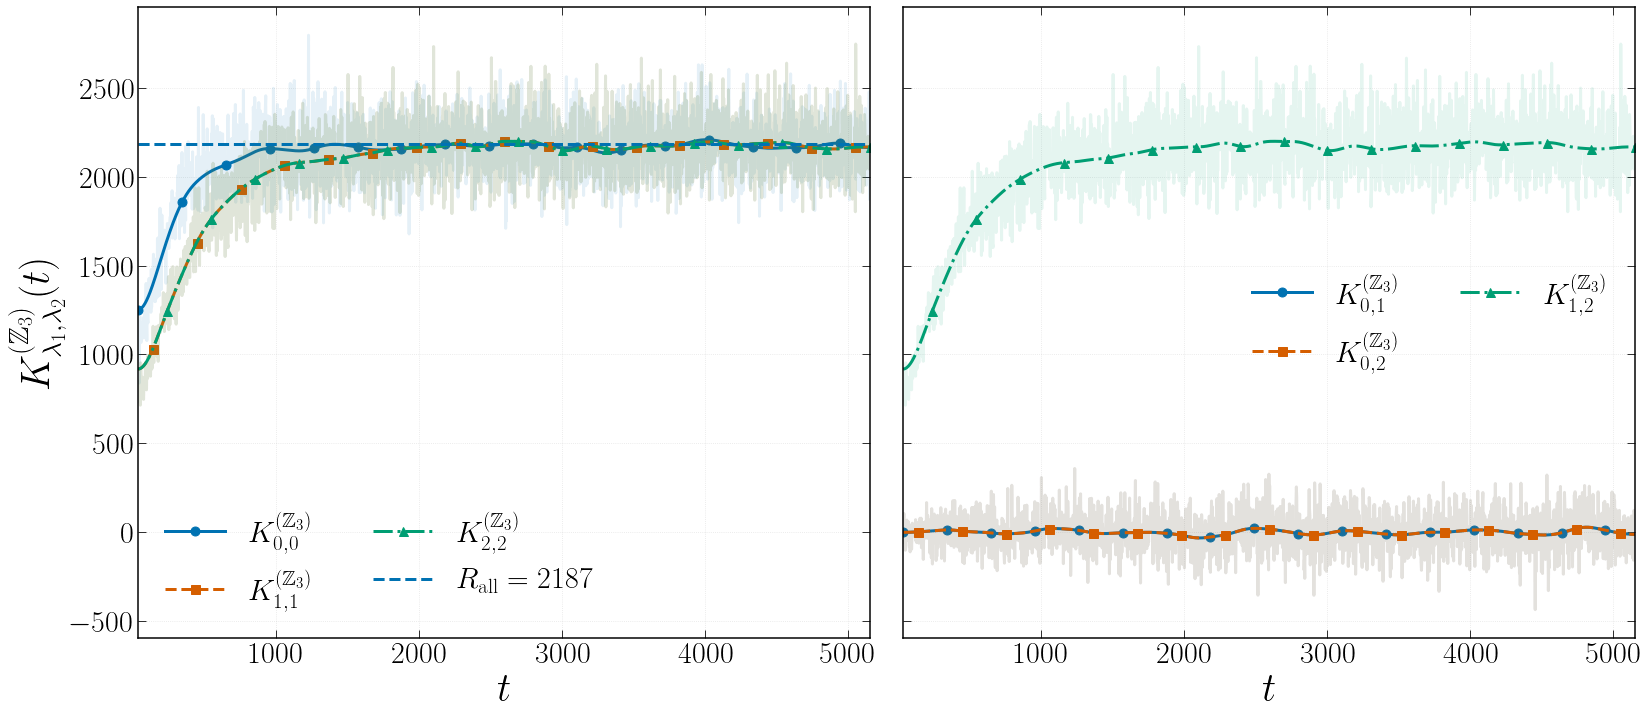

Saved paper_figure/spsff_z3_S3chain.pdf


In [19]:
labels_s3 = ["0", "1", "2"]

def kb_s3(i, j, smooth=True):
    ii, jj = min(i, j), max(i, j)
    p = "Ks" if smooth else "K"
    return f"{p}_{labels_s3[ii]}_{labels_s3[jj]}"

plot_spsff(
    npz_path=f"{DATA_ROOT}/S3_Chain_L8_th0.00_n200/spsff_data.npz",
    out_pdf=f"{OUT_DIR}/spsff_z3_S3chain.pdf",
    n_sec=3,
    sym_label=r"\mathbb{Z}_3",
    key_builder=kb_s3,
    disp_labels=["0", "1", "2"],
)

## D4 / KT Chain ($\mathbb{Z}_2 \times \mathbb{Z}_2$, 4 sectors: 00, 01, 10, 11)

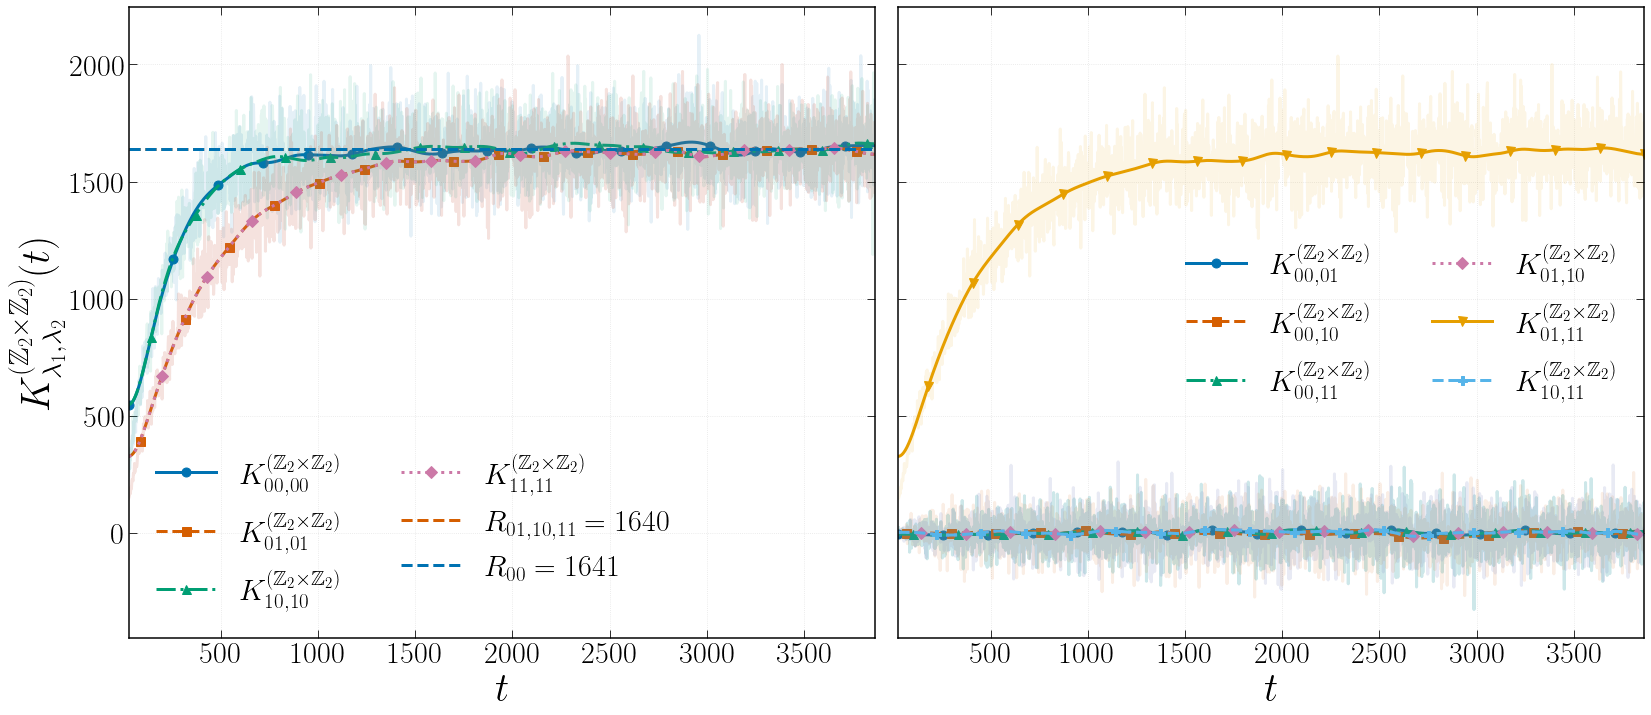

Saved paper_figure/spsff_z2z2_KTchain.pdf


In [20]:
labels_d4 = ["00", "01", "10", "11"]

def kb_d4(i, j, smooth=True):
    ii, jj = min(i, j), max(i, j)
    p = "Ks" if smooth else "K"
    return f"{p}_{labels_d4[ii]}_{labels_d4[jj]}"

plot_spsff(
    npz_path=f"{DATA_ROOT}/D4_Chain_L8_s0.25_n200/spsff_data.npz",
    out_pdf=f"{OUT_DIR}/spsff_z2z2_KTchain.pdf",
    n_sec=4,
    sym_label=r"\mathbb{Z}_2\times \mathbb{Z}_2",
    key_builder=kb_d4,
    disp_labels=["00", "01", "10", "11"],
)

## AT Potts ($\mathbb{Z}_2 \times \mathbb{Z}_2$, 4 sectors: 00, 10, 01, 11)

Note: sector order in the npz file is (00, 10, 01, 11), **not** (00, 01, 10, 11).

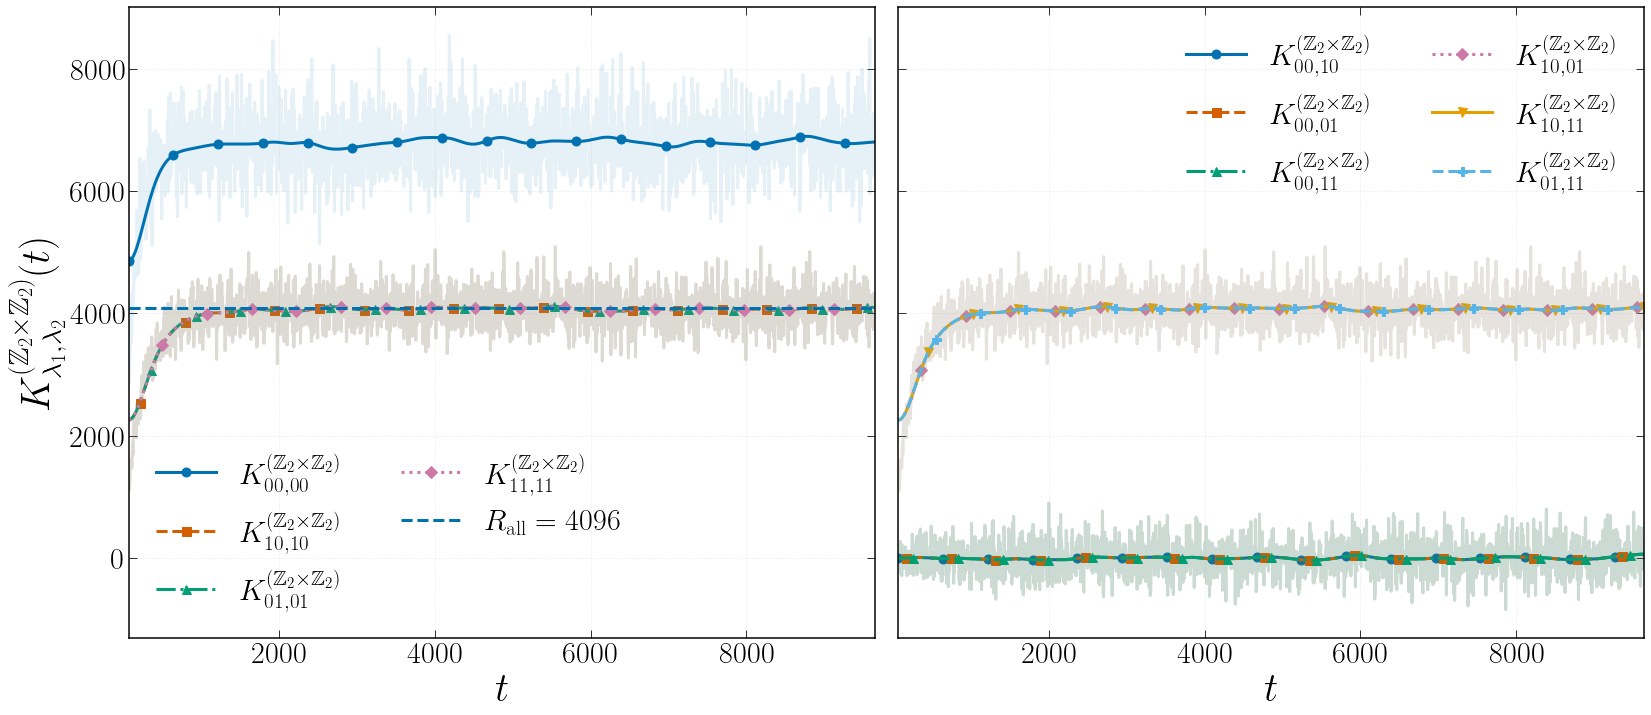

Saved paper_figure/spsff_z2z2_ATPotts.pdf


In [21]:
# AT sector order: (0,0), (1,0), (0,1), (1,1)
labels_at = ["00", "10", "01", "11"]

def kb_at(i, j, smooth=True):
    ii, jj = min(i, j), max(i, j)
    p = "Ks" if smooth else "K"
    return f"{p}_{labels_at[ii]}_{labels_at[jj]}"

plot_spsff(
    npz_path=f"{DATA_ROOT}/AT_Potts_L7_h1.0_n200/spsff_data.npz",
    out_pdf=f"{OUT_DIR}/spsff_z2z2_ATPotts.pdf",
    n_sec=4,
    sym_label=r"\mathbb{Z}_2\times \mathbb{Z}_2",
    key_builder=kb_at,
    disp_labels=["00", "10", "01", "11"],
)

## QTC ($\mathbb{Z}_3^2 \rtimes \mathbb{Z}_2$, 6 sectors)

Sector labels: `0_p`, `0_m`, `0_1`, `1_0`, `1_1`, `1_2`.  
NPZ keys use underscores between the two labels, e.g. `K_0_p_0_m`.

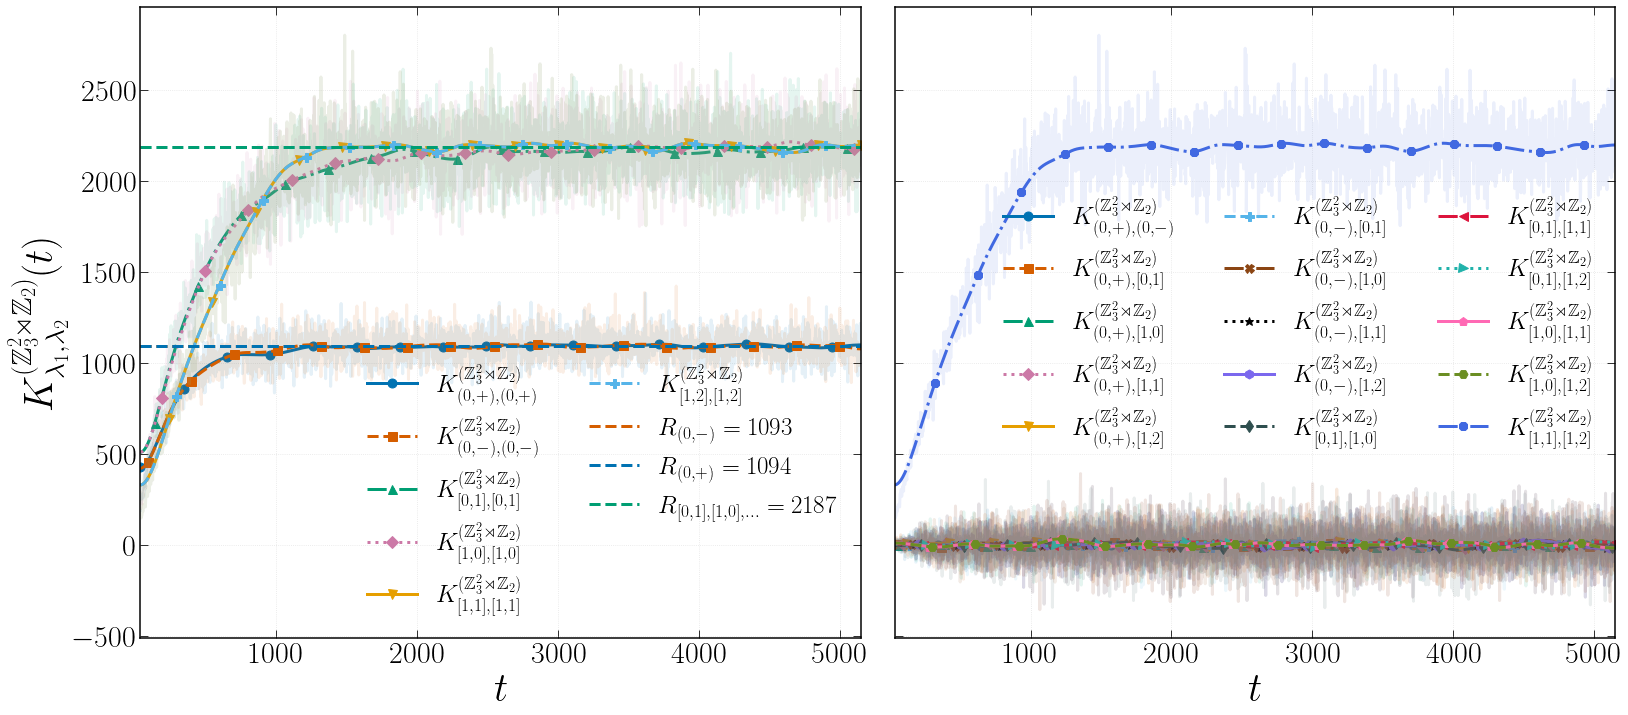

Saved paper_figure/spsff_QTC_L9_off.pdf


In [27]:
raw_qtc = ["0_p", "0_m", "0_1", "1_0", "1_1", "1_2"]

def kb_qtc(i, j, smooth=True):
    ii, jj = min(i, j), max(i, j)
    p = "Ks" if smooth else "K"
    return f"{p}_{raw_qtc[ii]}_{raw_qtc[jj]}"

plot_spsff(
    npz_path=f"{DATA_ROOT}/QTC_L9_th0.5236_n200/spsff_data.npz",
    out_pdf=f"{OUT_DIR}/spsff_QTC_L9_off.pdf",
    n_sec=6,
    sym_label=r"\mathbb{Z}_3^2\rtimes \mathbb{Z}_2",
    key_builder=kb_qtc,
    disp_labels=[r"(0{,}+)", r"(0{,}-)", r"[0{,}1]",
                 r"[1{,}0]", r"[1{,}1]", r"[1{,}2]"],
)

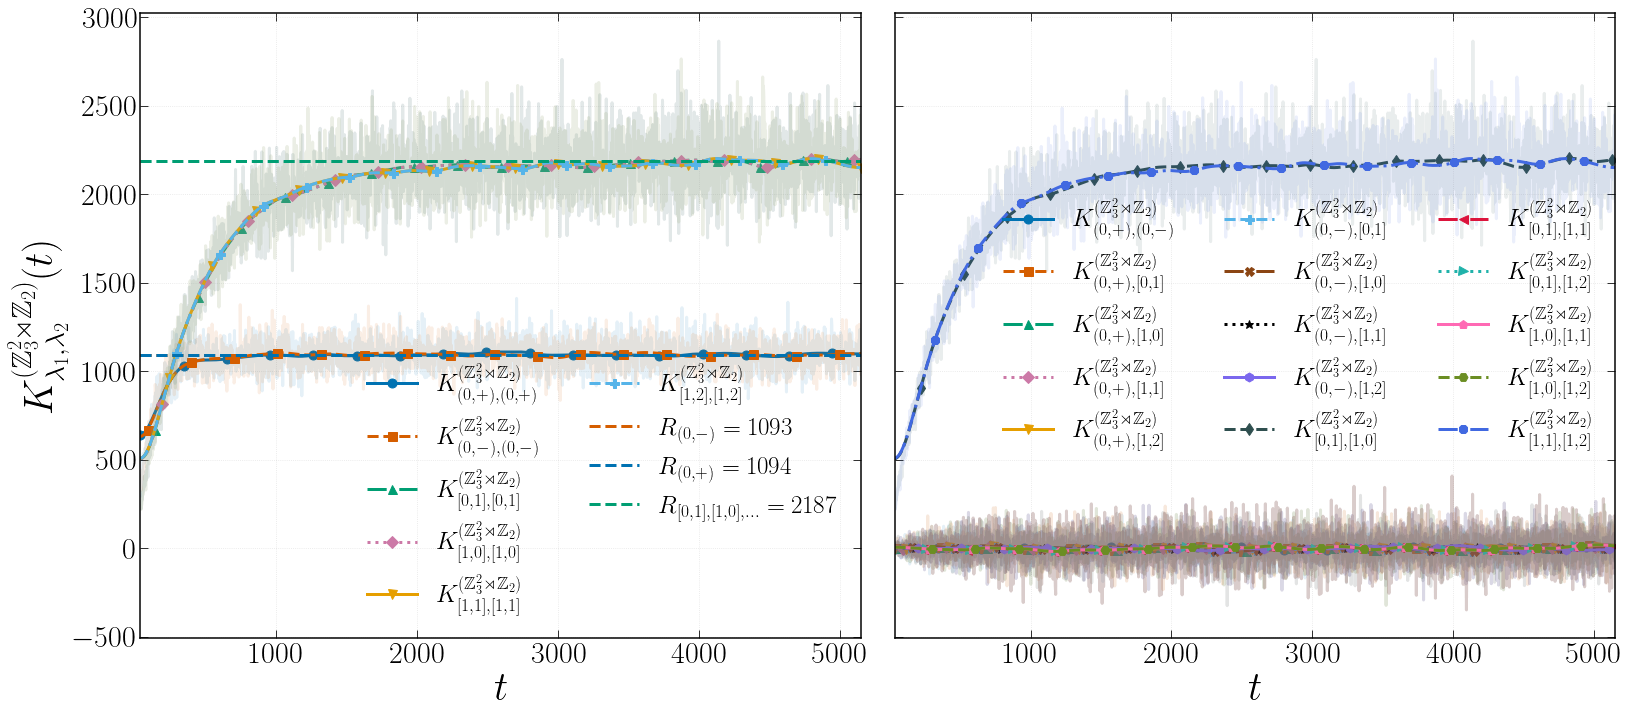

Saved paper_figure/spsff_QTC_L9.pdf


In [26]:
raw_qtc = ["0_p", "0_m", "0_1", "1_0", "1_1", "1_2"]

def kb_qtc(i, j, smooth=True):
    ii, jj = min(i, j), max(i, j)
    p = "Ks" if smooth else "K"
    return f"{p}_{raw_qtc[ii]}_{raw_qtc[jj]}"

plot_spsff(
    npz_path=f"{DATA_ROOT}/QTC_L9_th0.7854_n200/spsff_data.npz",
    out_pdf=f"{OUT_DIR}/spsff_QTC_L9.pdf",
    n_sec=6,
    sym_label=r"\mathbb{Z}_3^2\rtimes \mathbb{Z}_2",
    key_builder=kb_qtc,
    disp_labels=[r"(0{,}+)", r"(0{,}-)", r"[0{,}1]",
                 r"[1{,}0]", r"[1{,}1]", r"[1{,}2]"],
)

## KDBH ($D_L$ with $L=8$, $N=9$, 7 irreps)

Kinetically-Driven Bose-Hubbard model.  
$D_8$ irreps: 4 one-dimensional $(0,\pm), (4,\pm)$ and 3 two-dimensional $Q=1,2,3$.  
Normalization: $K/(d_{\lambda_1} d_{\lambda_2})$, benchmark $R_\lambda = \dim_\lambda / d_\lambda$.

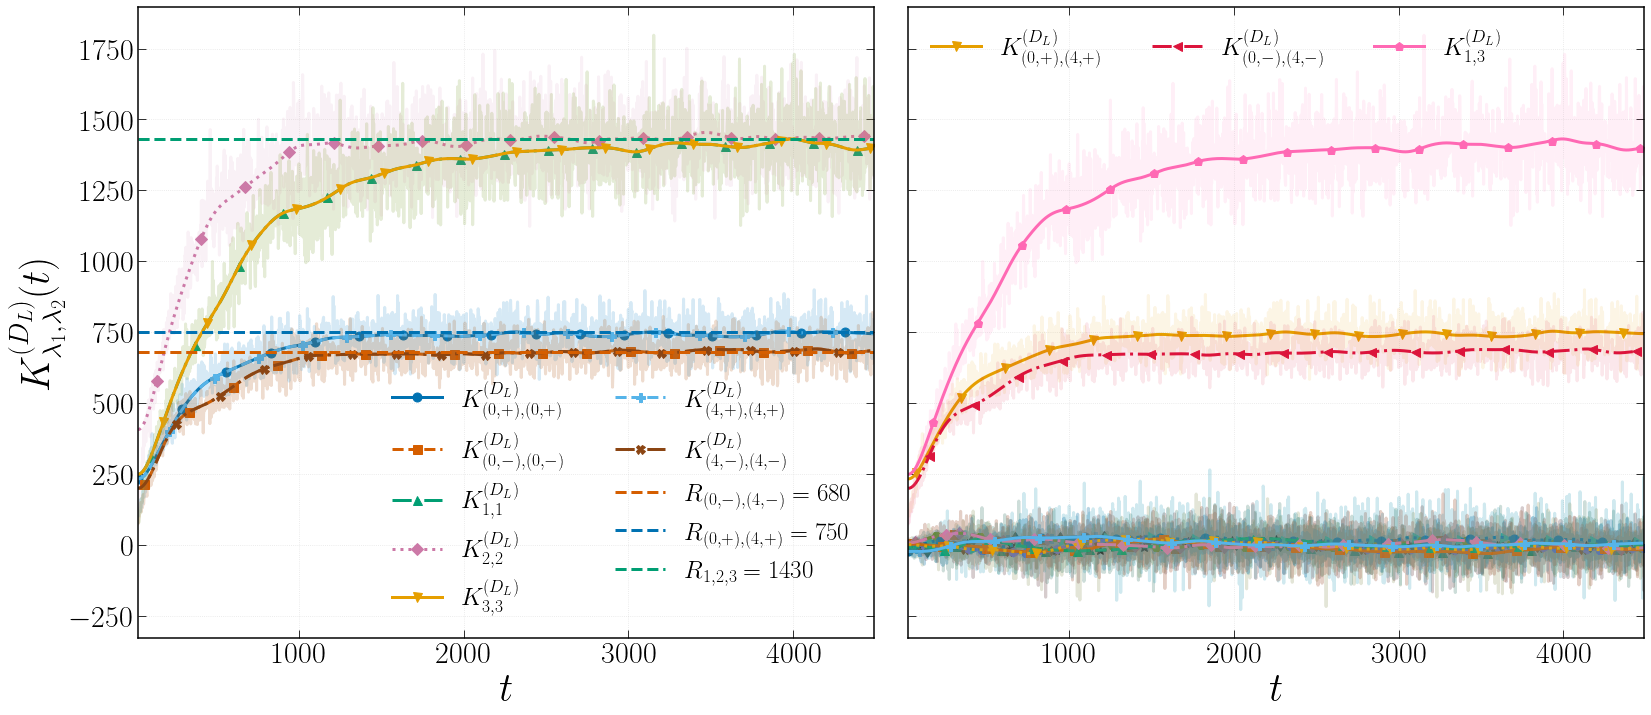

Saved paper_figure/spsff_DL_KDBH.pdf


In [39]:
KDBH_ROOT = "/home/zihanz/spsff/model_code/floquet_system"

# D_8 irrep labels: 4 x 1D + 3 x 2D
raw_kdbh = ["0_p", "0_m", "1", "2", "3", "4_p", "4_m"]
n_sec_kdbh = len(raw_kdbh)

npz_kdbh = f"{KDBH_ROOT}/KDBH_N9_L8_k0.9_s0.25_n200/spsff_data.npz"
d = np.load(npz_kdbh, allow_pickle=True)
t = d["t_calc"]
sector_dims = d["sector_dims"]
d_irreps    = d["d_irreps"]
R_bench     = sector_dims.astype(float) / d_irreps.astype(float)

# Load all K data
Ks, Kr = {}, {}
for i in range(n_sec_kdbh):
    for j in range(i, n_sec_kdbh):
        Ks[(i,j)] = d[f"Ks_{raw_kdbh[i]}_{raw_kdbh[j]}"]
        Kr[(i,j)] = d[f"K_{raw_kdbh[i]}_{raw_kdbh[j]}"]

# Display labels
disp_kdbh = [r"(0{,}+)", r"(0{,}-)", r"1", r"2", r"3", r"(4{,}+)", r"(4{,}-)"]

sym_label = r"D_L"
t_start, t_end = t[0], t[-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18*1.3, 8*1.3), sharey=True)

# ── Panel 1: diagonal K_{lambda,lambda} ──
for i in range(n_sec_kdbh):
    sub = disp_kdbh[i]
    col = PALETTE[i % len(PALETTE)]
    mk  = MARKERS[i % len(MARKERS)]
    ls  = LINESTYLES[i % len(LINESTYLES)]
    offset = i * mark_period // max(n_sec_kdbh, 1)
    label = rf"$K^{{({sym_label})}}_{{ {sub},{sub} }}$"
    ax1.plot(t, Ks[(i,i)], color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period),
             markersize=mark_size, label=label)
    ax1.plot(t, Kr[(i,i)], color=col, lw=lw_smooth, alpha=0.1)

# Benchmark lines: merge by value
bench_groups = {}
for i in range(n_sec_kdbh):
    val = round(R_bench[i])
    bench_groups.setdefault(val, []).append((i, disp_kdbh[i]))
for val, members in sorted(bench_groups.items()):
    if len(members) == n_sec_kdbh:
        combined_label = r"\text{all}"
    elif len(members) > 3:
        combined_label = ",".join(m[1] for m in members[:2]) + r",\ldots"
    else:
        combined_label = ",".join(m[1] for m in members)
    col = PALETTE[members[0][0] % len(PALETTE)]
    ax1.axhline(y=val, color=col, ls="--", lw=3.0, alpha=1.0,
                label=rf"$R_{{{combined_label}}}={val:.0f}$")

ax1.set_xlabel(r"$t$", fontsize=40)
ax1.tick_params(labelsize=30)
ax1.set_ylabel(rf"$K^{{({sym_label})}}_{{ \lambda_1,\lambda_2 }}(t)$", fontsize=40)
ax1.legend(ncol=2, fontsize=25)
ax1.grid(True, ls=":", alpha=0.35)
ax1.set_xlim(t_start, t_end)

# ── Panel 2: off-diagonal ──
off_pairs = [(i, j) for i in range(n_sec_kdbh) for j in range(i+1, n_sec_kdbh)]
n_off = len(off_pairs)
for ci, (i, j) in enumerate(off_pairs):
    s1, s2 = disp_kdbh[i], disp_kdbh[j]
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_off, 1)
    label = rf"$K^{{({sym_label})}}_{{ {s1},{s2} }}$"
    if Ks[(i,j)].max()<100:
        # If the smoothed K is zero, it's likely that the off-diagonal sector is empty.
        ax2.plot(t, Ks[(i,j)],
                color=col, lw=lw_smooth, ls=ls,
                marker=mk, markevery=(offset, mark_period),
                markersize=mark_size)
    else:
        ax2.plot(t, Ks[(i,j)],
                 color=col, lw=lw_smooth, ls=ls,
                 marker=mk, markevery=(offset, mark_period),
                 markersize=mark_size, label=label)
    
    ax2.plot(t, Kr[(i,j)],
             color=col, lw=lw_smooth, alpha=0.1)

ax2.set_xlabel(r"$t$", fontsize=40)
ax2.tick_params(labelsize=30)
ax2.legend(ncol=3, fontsize=25)
ax2.grid(True, ls=":", alpha=0.35)
ax2.set_xlim(t_start, t_end)

plt.tight_layout()
out_pdf = f"{OUT_DIR}/spsff_DL_KDBH.pdf"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved {out_pdf}")

## Fermi-Hubbard ($U(1)_\text{charge} \times U(1)_\text{spin}$, 61 sectors)

1D Fermi-Hubbard model with disordered hopping, $L=8$.  
Visible symmetry: $\mathcal{N} = U(1)_N \times U(1)_{S^z}$, sectors labeled by $(S^z, N)$.  
Hidden symmetry: $G = SU(2)_\eta$ ($\eta$-pairing, Yang 1989).  
Sector dimension $= \binom{L}{N_\uparrow}\binom{L}{N_\downarrow}$, all $d_\lambda = 1$, $\nu=1$, so $R_\lambda = \mathrm{dim}_\lambda$.

**Panel 1 (diagonal)**: raw $K$ with $R_\lambda = \mathrm{dim}$ as dashed benchmarks.  
**Panel 2**: Off-diagonal within $S^z=0$ ($\eta$-staircase) — raw $K$.  
**Panel 3**: Cross-$S^z$ selection rule — raw $K$.

npz labels: `"{2Sz}.{N}"`, e.g. `"0.8"` = $(S^z\!=\!0, N\!=\!8)$, `"1.7"` = $(S^z\!=\!\tfrac12, N\!=\!7)$.

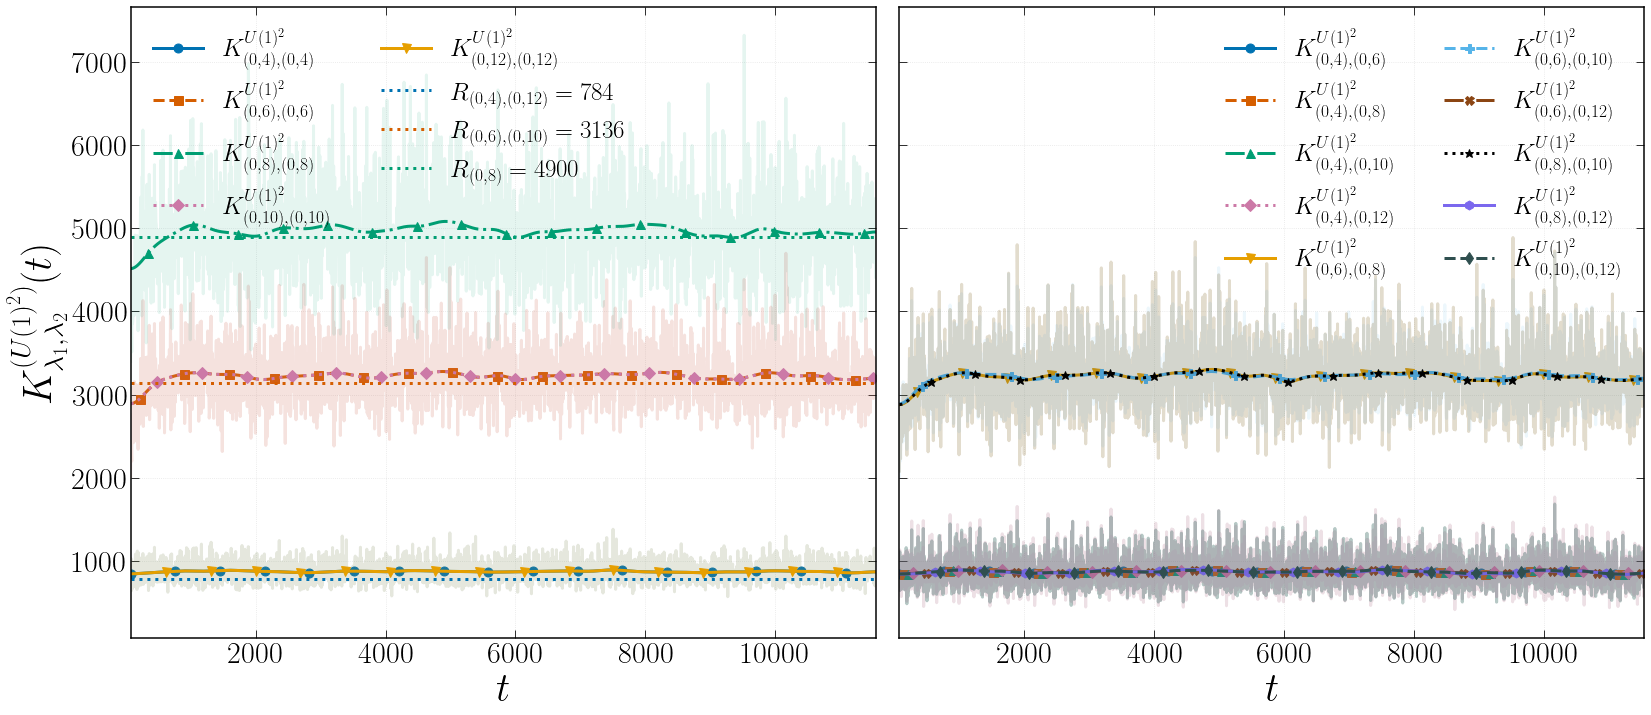

Saved paper_figure/spsff_U1xU1_Hubbard.pdf


In [31]:
npz_hub2 = f"{DATA_ROOT}/Hubbard_U1xU1_L8_U4.0_t3.0_s0.5_n200/spsff_data.npz"
d = np.load(npz_hub2, allow_pickle=True)
t = d["t_calc"]

sector_keys  = list(d["sector_keys"])
sector_twoSz = d["sector_twoSz"]
sector_N     = d["sector_N"]
sector_dims  = d["sector_dims"]
d_irreps     = d["d_irreps"]
nu           = d["nu"]
n_sec        = len(sector_keys)
L_hub        = int(d["L"])
t_start, t_end = t[0], t[-1]

# R_lambda = nu * sector_dims / d_irreps  (all 1s here, so R = sector_dims)
R_bench = nu.astype(float) * sector_dims.astype(float) / d_irreps.astype(float)

# Load all K data
Ks, Kr = {}, {}
for i in range(n_sec):
    for j in range(i, n_sec):
        l1, l2 = sector_keys[i], sector_keys[j]
        Ks[(i,j)] = d[f"Ks_{l1}_{l2}"]
        Kr[(i,j)] = d[f"K_{l1}_{l2}"]

# ── Helper: select sectors by 2Sz value ──
def sectors_with_twoSz(val):
    """Return list of (index, label, N, dim) for sectors with given 2Sz."""
    return [(i, sector_keys[i], int(sector_N[i]), int(sector_dims[i]))
            for i in range(n_sec)
            if sector_twoSz[i] == val and sector_dims[i] > 1]

sym_label = r"U(1)^2"

# ── 2-panel figure ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18*1.3, 8*1.3), sharey=True)

# ── Panel 1: diagonal raw K with R_lambda benchmarks ──
secs_sz0 = sectors_with_twoSz(0)
secs_sz1 = sectors_with_twoSz(1)
n_diag = len(secs_sz0)
for ci, (idx, lab, N, dim) in enumerate(secs_sz0):
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_diag, 1)
    ax1.plot(t, Ks[(idx,idx)],
             color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period), markersize=mark_size,
             label=rf"$K_{{(0,{N}),(0,{N})}}^{{U(1)^2}}$")
    ax1.plot(t, Kr[(idx,idx)],
             color=col, lw=lw_smooth, alpha=0.1)

# Benchmark lines: merge by value
bench_groups = {}
for ci, (idx, lab, N, dim) in enumerate(secs_sz0):
    val = round(R_bench[idx])
    bench_groups.setdefault(val, []).append((ci, f"(0,{N})"))
for val, members in sorted(bench_groups.items()):
    if len(members) > 3:
        combined_label = ",".join(m[1] for m in members[:2]) + r",\ldots"
    else:
        combined_label = ",".join(m[1] for m in members)
    col = PALETTE[members[0][0] % len(PALETTE)]
    ax1.axhline(y=val, color=col, ls=":", lw=3.0, alpha=1.0,
                label=rf"$R_{{{combined_label}}}={int(val)}$")

ax1.set_xlabel(r"$t$", fontsize=40)
ax1.tick_params(labelsize=30)
ax1.set_ylabel(rf"$K^{{({sym_label})}}_{{ \lambda_1,\lambda_2 }}(t)$", fontsize=40)
ax1.legend(ncol=2,fontsize=25)
ax1.grid(True, ls=":", alpha=0.35)
ax1.set_xlim(t_start, t_end)

# ── Panel 2: off-diagonal within Sz=0 (η-staircase, raw K) ──
off_sz0 = [(secs_sz0[a], secs_sz0[b])
           for a in range(len(secs_sz0))
           for b in range(a+1, len(secs_sz0))]
n_off = len(off_sz0)
for ci, ((i1,l1,N1,d1), (i2,l2,N2,d2)) in enumerate(off_sz0):
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_off, 1)
    ax2.plot(t, Ks[(i1,i2)],
             color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period), markersize=mark_size,
             label=rf"$K_{{(0,{N1}),(0,{N2})}}^{{U(1)^2}}$")
    ax2.plot(t, Kr[(i1,i2)],
             color=col, lw=lw_smooth, alpha=0.1)

ax2.set_xlabel(r"$t$", fontsize=40)
ax2.tick_params(labelsize=30)
ax2.legend(ncol=2,fontsize=25)
ax2.grid(True, ls=":", alpha=0.35)
ax2.set_xlim(t_start, t_end)

plt.tight_layout()
out_pdf = f"{OUT_DIR}/spsff_U1xU1_Hubbard.pdf"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved {out_pdf}")

## Fermi-Hubbard with random $U$ ($U(1)_\text{charge} \times U(1)_\text{spin}$, $L=8$)

Same model as above but with **both** disordered hopping and disordered global $U$:
$t_j \sim \mathcal{N}(1, 0.5^2)$, $U \sim \mathcal{N}(4, 0.5^2)$ (one global $U$ per realization).

Data: `Hubbard_U1xU1_L8_U4.0_sU0.5_s0.5_n200/spsff_data.npz`

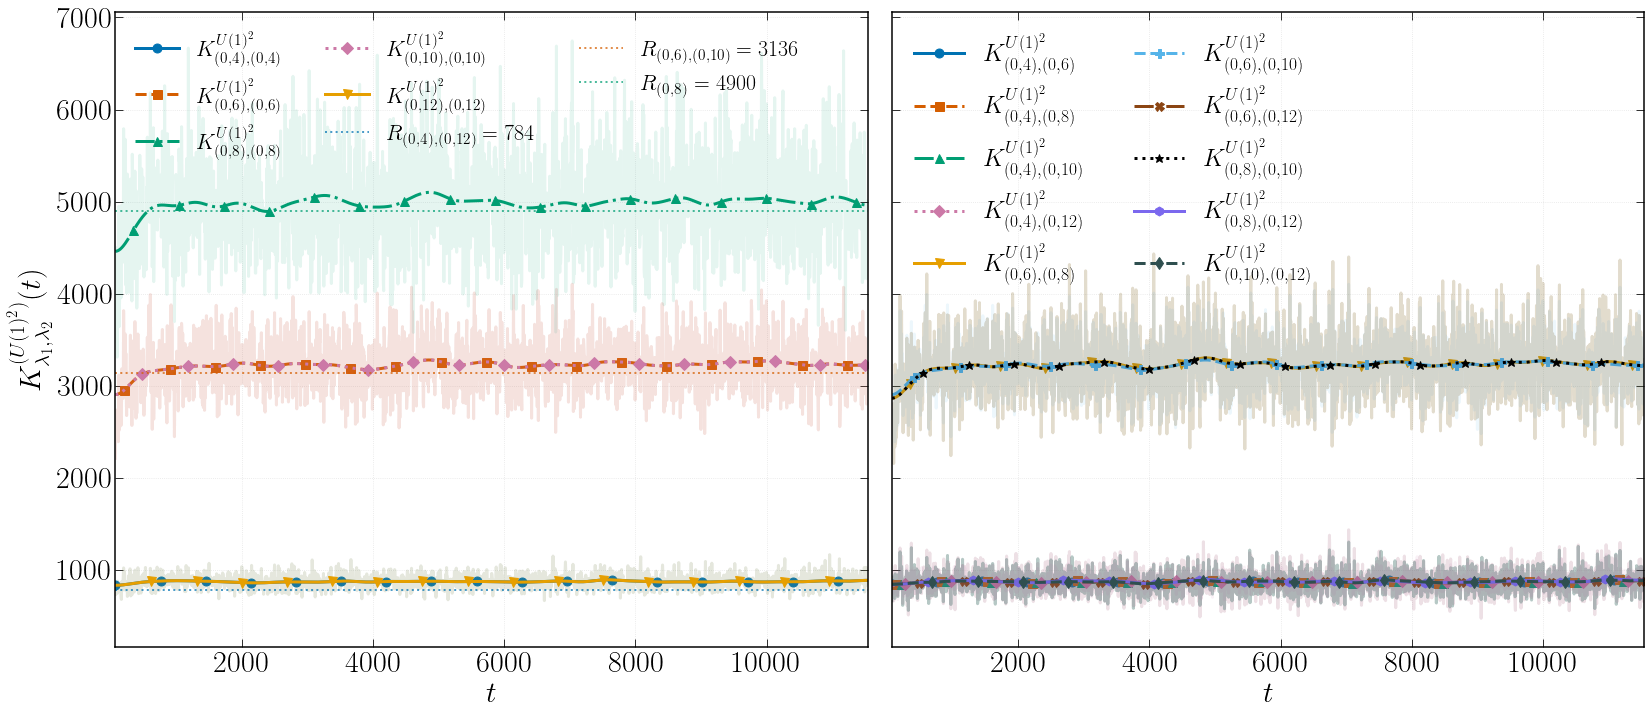

Saved paper_figure/spsff_U1xU1_Hubbard_randU.pdf


In [32]:
npz_hub_rU = f"{DATA_ROOT}/Hubbard_U1xU1_L8_U4.0_t3.0_sU0.5_s0.5_n200/spsff_data.npz"
d = np.load(npz_hub_rU, allow_pickle=True)
t = d["t_calc"]

sector_keys  = list(d["sector_keys"])
sector_twoSz = d["sector_twoSz"]
sector_N     = d["sector_N"]
sector_dims  = d["sector_dims"]
d_irreps     = d["d_irreps"]
nu           = d["nu"]
n_sec        = len(sector_keys)
t_start, t_end = t[0], t[-1]

R_bench = nu.astype(float) * sector_dims.astype(float) / d_irreps.astype(float)

# Load all K data
Ks, Kr = {}, {}
for i in range(n_sec):
    for j in range(i, n_sec):
        l1, l2 = sector_keys[i], sector_keys[j]
        Ks[(i,j)] = d[f"Ks_{l1}_{l2}"]
        Kr[(i,j)] = d[f"K_{l1}_{l2}"]

def sectors_with_twoSz(val):
    return [(i, sector_keys[i], int(sector_N[i]), int(sector_dims[i]))
            for i in range(n_sec)
            if sector_twoSz[i] == val and sector_dims[i] > 1]

sym_label = r"U(1)^2"
secs_sz0 = sectors_with_twoSz(0)
secs_sz1 = sectors_with_twoSz(1)

# ── 2-panel figure (same layout as fixed-U cell above) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18*1.3, 8*1.3), sharey=True)

# ── Panel 1: diagonal raw K with R_lambda benchmarks (Sz=0) ──
n_diag = len(secs_sz0)
for ci, (idx, lab, N, dim) in enumerate(secs_sz0):
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_diag, 1)
    ax1.plot(t, Ks[(idx,idx)],
             color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period), markersize=mark_size,
             label=rf"$K_{{(0,{N}),(0,{N})}}^{{U(1)^2}}$")
    ax1.plot(t, Kr[(idx,idx)],
             color=col, lw=lw_smooth, alpha=0.1)

# Benchmark lines: merge by value
bench_groups = {}
for ci, (idx, lab, N, dim) in enumerate(secs_sz0):
    val = round(R_bench[idx])
    bench_groups.setdefault(val, []).append((ci, f"(0,{N})"))
for val, members in sorted(bench_groups.items()):
    if len(members) > 3:
        combined_label = ",".join(m[1] for m in members[:2]) + r",\ldots"
    else:
        combined_label = ",".join(m[1] for m in members)
    col = PALETTE[members[0][0] % len(PALETTE)]
    ax1.axhline(y=val, color=col, ls=":", lw=2.0, alpha=0.7,
                label=rf"$R_{{{combined_label}}}={int(val)}$")

ax1.set_xlabel(r"$t$", fontsize=30)
ax1.tick_params(labelsize=30)
ax1.set_ylabel(rf"$K^{{({sym_label})}}_{{ \lambda_1,\lambda_2 }}(t)$", fontsize=30)
ax1.legend(ncol=3, fontsize=22)
ax1.grid(True, ls=":", alpha=0.35)
ax1.set_xlim(t_start, t_end)

# ── Panel 2: off-diagonal within Sz=0 (η-staircase) ──
off_sz0 = [(secs_sz0[a], secs_sz0[b])
           for a in range(len(secs_sz0))
           for b in range(a+1, len(secs_sz0))]
n_off = len(off_sz0)
for ci, ((i1,l1,N1,d1), (i2,l2,N2,d2)) in enumerate(off_sz0):
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_off, 1)
    ax2.plot(t, Ks[(i1,i2)],
             color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period), markersize=mark_size,
             label=rf"$K_{{(0,{N1}),(0,{N2})}}^{{U(1)^2}}$")
    ax2.plot(t, Kr[(i1,i2)],
             color=col, lw=lw_smooth, alpha=0.1)

ax2.set_xlabel(r"$t$", fontsize=30)
ax2.tick_params(labelsize=30)
ax2.legend(ncol=2, fontsize=25)
ax2.grid(True, ls=":", alpha=0.35)
ax2.set_xlim(t_start, t_end)

plt.tight_layout()
out_pdf = f"{OUT_DIR}/spsff_U1xU1_Hubbard_randU.pdf"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved {out_pdf}")

## Fermi-Hubbard, uniform hopping, fixed $U$ ($L=8$)

Clean model: $t_j = t_0 = 3.0$ (no disorder), $U = 4.0$ fixed, single realization.  
Data: `Hubbard_U1xU1_L8_U4.0_t3.0_s0.0_n1`

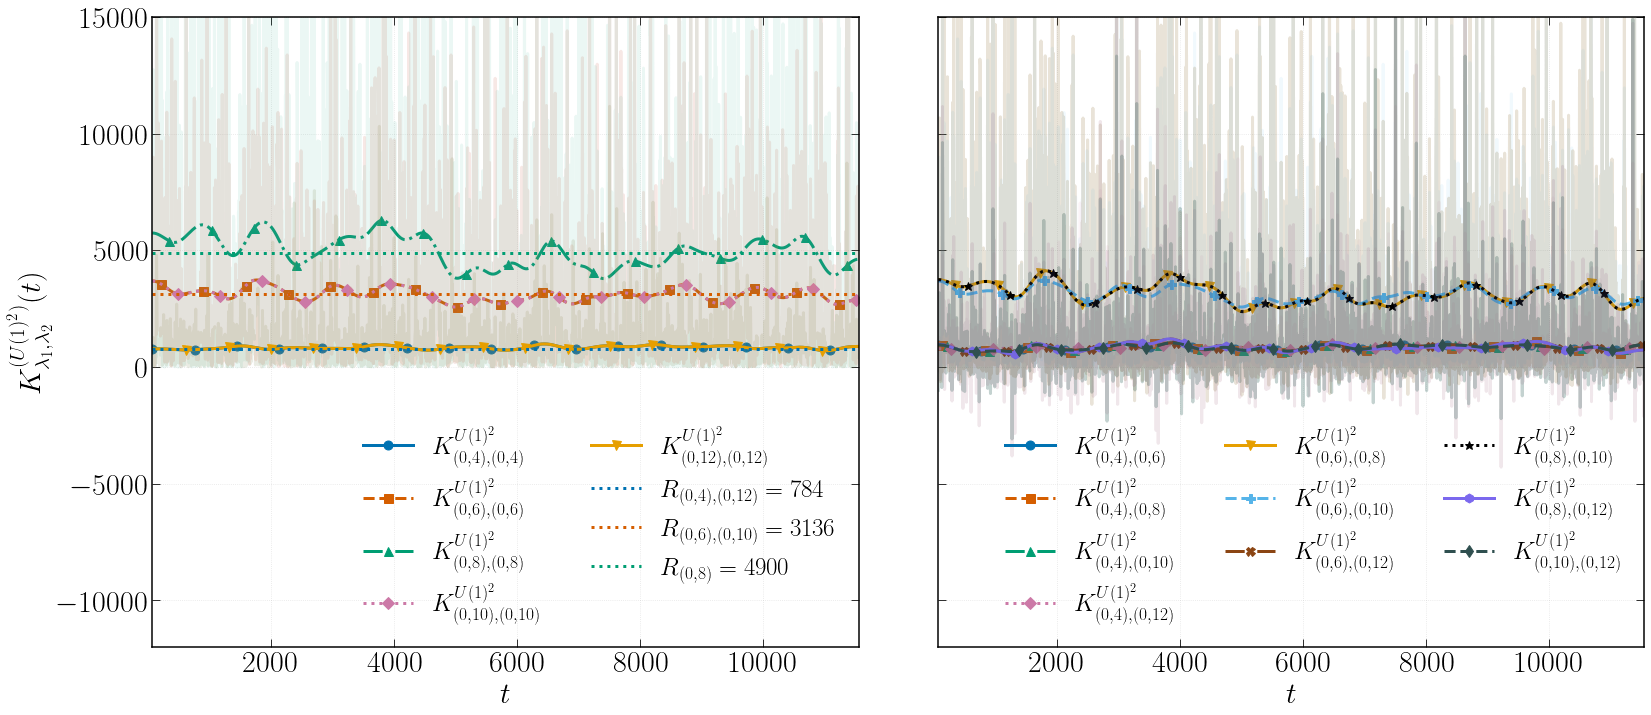

Saved paper_figure/spsff_U1xU1_Hubbard_clean_fixedU.pdf


In [22]:
npz_hub_clean = f"{DATA_ROOT}/Hubbard_U1xU1_L8_U4.0_t3.0_s0.0_n1/spsff_data.npz"
d = np.load(npz_hub_clean, allow_pickle=True)
t = d["t_calc"]

sector_keys  = list(d["sector_keys"])
sector_twoSz = d["sector_twoSz"]
sector_N     = d["sector_N"]
sector_dims  = d["sector_dims"]
d_irreps     = d["d_irreps"]
nu           = d["nu"]
n_sec        = len(sector_keys)
t_start, t_end = t[0], t[-1]

R_bench = nu.astype(float) * sector_dims.astype(float) / d_irreps.astype(float)

Ks, Kr = {}, {}
for i in range(n_sec):
    for j in range(i, n_sec):
        l1, l2 = sector_keys[i], sector_keys[j]
        Ks[(i,j)] = d[f"Ks_{l1}_{l2}"]
        Kr[(i,j)] = d[f"K_{l1}_{l2}"]

def sectors_with_twoSz(val):
    return [(i, sector_keys[i], int(sector_N[i]), int(sector_dims[i]))
            for i in range(n_sec)
            if sector_twoSz[i] == val and sector_dims[i] > 1]

sym_label = r"U(1)^2"
secs_sz0 = sectors_with_twoSz(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18*1.3, 8*1.3), sharey=True)

leg_kw = dict(fontsize=25, facecolor='white', framealpha=1.0,
              edgecolor='gray', loc='lower right')

# ── Panel 1: diagonal raw K (Sz=0) ──
n_diag = len(secs_sz0)
for ci, (idx, lab, N, dim) in enumerate(secs_sz0):
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_diag, 1)
    ax1.plot(t, Ks[(idx,idx)],
             color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period), markersize=mark_size,
             label=rf"$K_{{(0,{N}),(0,{N})}}^{{U(1)^2}}$")
    ax1.plot(t, Kr[(idx,idx)],
             color=col, lw=lw_smooth, alpha=0.08)

bench_groups = {}
for ci, (idx, lab, N, dim) in enumerate(secs_sz0):
    val = round(R_bench[idx])
    bench_groups.setdefault(val, []).append((ci, f"(0,{N})"))
for val, members in sorted(bench_groups.items()):
    if len(members) > 3:
        combined_label = ",".join(m[1] for m in members[:2]) + r",\ldots"
    else:
        combined_label = ",".join(m[1] for m in members)
    col = PALETTE[members[0][0] % len(PALETTE)]
    ax1.axhline(y=val, color=col, ls=":", lw=3.0, alpha=1.0,
                label=rf"$R_{{{combined_label}}}={int(val)}$")

ax1.set_xlabel(r"$t$", fontsize=30)
ax1.tick_params(labelsize=30)
ax1.set_ylabel(rf"$K^{{({sym_label})}}_{{ \lambda_1,\lambda_2 }}(t)$", fontsize=30)
ax1.legend(ncol=2, **leg_kw)
ax1.grid(True, ls=":", alpha=0.35)
ax1.set_xlim(t_start, t_end)
ax1.set_ylim(-12000,15000)

# ── Panel 2: off-diagonal within Sz=0 ──
off_sz0 = [(secs_sz0[a], secs_sz0[b])
           for a in range(len(secs_sz0))
           for b in range(a+1, len(secs_sz0))]
n_off = len(off_sz0)
for ci, ((i1,l1,N1,d1), (i2,l2,N2,d2)) in enumerate(off_sz0):
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_off, 1)
    ax2.plot(t, Ks[(i1,i2)],
             color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period), markersize=mark_size,
             label=rf"$K_{{(0,{N1}),(0,{N2})}}^{{U(1)^2}}$")
    ax2.plot(t, Kr[(i1,i2)],
             color=col, lw=lw_smooth, alpha=0.08)

ax2.set_xlabel(r"$t$", fontsize=30)
ax2.tick_params(labelsize=30)
ax2.legend(ncol=3, **leg_kw)
ax2.grid(True, ls=":", alpha=0.35)
ax2.set_xlim(t_start, t_end)
ax2.set_ylim(-12000,15000)

plt.tight_layout()
out_pdf = f"{OUT_DIR}/spsff_U1xU1_Hubbard_clean_fixedU.pdf"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved {out_pdf}")

## Fermi-Hubbard, uniform hopping, random $U$ ($L=8$)

Clean hopping: $t_j = t_0 = 3.0$ (no disorder), $U \sim \mathcal{N}(4, 0.5^2)$, 200 realizations.  
Data: `Hubbard_U1xU1_L8_U4.0_t3.0_sU0.5_s0.0_n200`

In [ ]:
npz_hub_clean_rU = f"{DATA_ROOT}/Hubbard_U1xU1_L8_U4.0_t3.0_sU0.5_s0.0_n200/spsff_data.npz"
d = np.load(npz_hub_clean_rU, allow_pickle=True)
t = d["t_calc"]

sector_keys  = list(d["sector_keys"])
sector_twoSz = d["sector_twoSz"]
sector_N     = d["sector_N"]
sector_dims  = d["sector_dims"]
d_irreps     = d["d_irreps"]
nu           = d["nu"]
n_sec        = len(sector_keys)
t_start, t_end = t[0], t[-1]

R_bench = nu.astype(float) * sector_dims.astype(float) / d_irreps.astype(float)

Ks, Kr = {}, {}
for i in range(n_sec):
    for j in range(i, n_sec):
        l1, l2 = sector_keys[i], sector_keys[j]
        Ks[(i,j)] = d[f"Ks_{l1}_{l2}"]
        Kr[(i,j)] = d[f"K_{l1}_{l2}"]

def sectors_with_twoSz(val):
    return [(i, sector_keys[i], int(sector_N[i]), int(sector_dims[i]))
            for i in range(n_sec)
            if sector_twoSz[i] == val and sector_dims[i] > 1]

sym_label = r"U(1)^2"
secs_sz0 = sectors_with_twoSz(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18*1.3, 8*1.3), sharey=True)

# ── Panel 1: diagonal raw K (Sz=0) ──
n_diag = len(secs_sz0)
for ci, (idx, lab, N, dim) in enumerate(secs_sz0):
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_diag, 1)
    ax1.plot(t, Ks[(idx,idx)],
             color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period), markersize=mark_size,
             label=rf"$K_{{(0,{N}),(0,{N})}}^{{U(1)^2}}$")
    ax1.plot(t, Kr[(idx,idx)],
             color=col, lw=lw_smooth, alpha=0.1)

bench_groups = {}
for ci, (idx, lab, N, dim) in enumerate(secs_sz0):
    val = round(R_bench[idx])
    bench_groups.setdefault(val, []).append((ci, f"(0,{N})"))
for val, members in sorted(bench_groups.items()):
    if len(members) > 3:
        combined_label = ",".join(m[1] for m in members[:2]) + r",\ldots"
    else:
        combined_label = ",".join(m[1] for m in members)
    col = PALETTE[members[0][0] % len(PALETTE)]
    ax1.axhline(y=val, color=col, ls=":", lw=3.0, alpha=1.0,
                label=rf"$R_{{{combined_label}}}={int(val)}$")

ax1.set_xlabel(r"$t$", fontsize=40)
ax1.tick_params(labelsize=30)
ax1.set_ylabel(rf"$K^{{({sym_label})}}_{{ \lambda_1,\lambda_2 }}(t)$", fontsize=40)
ax1.legend(ncol=2, fontsize=25)
ax1.grid(True, ls=":", alpha=0.35)
ax1.set_xlim(t_start, t_end)

# ── Panel 2: off-diagonal within Sz=0 ──
off_sz0 = [(secs_sz0[a], secs_sz0[b])
           for a in range(len(secs_sz0))
           for b in range(a+1, len(secs_sz0))]
n_off = len(off_sz0)
for ci, ((i1,l1,N1,d1), (i2,l2,N2,d2)) in enumerate(off_sz0):
    col = PALETTE[ci % len(PALETTE)]
    mk  = MARKERS[ci % len(MARKERS)]
    ls  = LINESTYLES[ci % len(LINESTYLES)]
    offset = ci * mark_period // max(n_off, 1)
    ax2.plot(t, Ks[(i1,i2)],
             color=col, lw=lw_smooth, ls=ls,
             marker=mk, markevery=(offset, mark_period), markersize=mark_size,
             label=rf"$K_{{(0,{N1}),(0,{N2})}}^{{U(1)^2}}$")
    ax2.plot(t, Kr[(i1,i2)],
             color=col, lw=lw_smooth, alpha=0.1)

ax2.set_xlabel(r"$t$", fontsize=40)
ax2.tick_params(labelsize=30)
ax2.legend(ncol=2, fontsize=25)
ax2.grid(True, ls=":", alpha=0.35)
ax2.set_xlim(t_start, t_end)

plt.tight_layout()
out_pdf = f"{OUT_DIR}/spsff_U1xU1_Hubbard_clean_randU.pdf"
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved {out_pdf}")